In [2]:
# Performance Optimization Starter Code
import pandas as pd
import numpy as np
import time
import joblib
from sklearn.metrics import classification_report

print("🚀 WEEK 4: Performance Optimization")
print("=" * 50)

# Load your trained model
model = joblib.load('fraud_detection_model.pkl')
feature_columns = joblib.load('feature_columns.pkl')

print("✅ Model loaded - ready for performance optimization!")
print(f"Model type: {type(model).__name__}")
print(f"Features: {len(feature_columns)}")


🚀 WEEK 4: Performance Optimization
✅ Model loaded - ready for performance optimization!
Model type: RandomForestClassifier
Features: 7


🚀 WEEK 4: Performance Optimization
🎯 Goals: Faster inference, lower memory, production-ready performance
✅ Libraries imported

📦 Loading model and data...
✅ Data loaded: (50000, 7)
✅ Model: RandomForestClassifier
✅ Features: 7

📊 1. PERFORMANCE BENCHMARKING
Running performance benchmarks...

🎯 PERFORMANCE RESULTS:
   Prediction Time: 23.03 ms per 1000 claims
   Probability Time: 20.82 ms per 1000 claims
   Predictions/sec: 43,414
   Probabilities/sec: 48,039
   Memory Used: 0.3 MB

📦 2. BATCH PROCESSING OPTIMIZATION
Testing different batch sizes...

📈 BATCH SIZE OPTIMIZATION:
   batch_size  time_ms  throughput
0         100    12.03     8315.10
1         500    18.50    27031.08
2        1000    24.69    40508.24
3        5000    45.31   110341.00
4       10000    77.57   128907.96

🎯 OPTIMAL BATCH SIZE: 10,000.0 claims
   Throughput: 128,908 claims/second

💾 3. MEMORY OPTIMIZATION
Analyzing memory usage...

📊 MEMORY USAGE BREAKDOWN:
   Model Size: 0.00 MB
   Data Size: 2.67 MB
   Pred

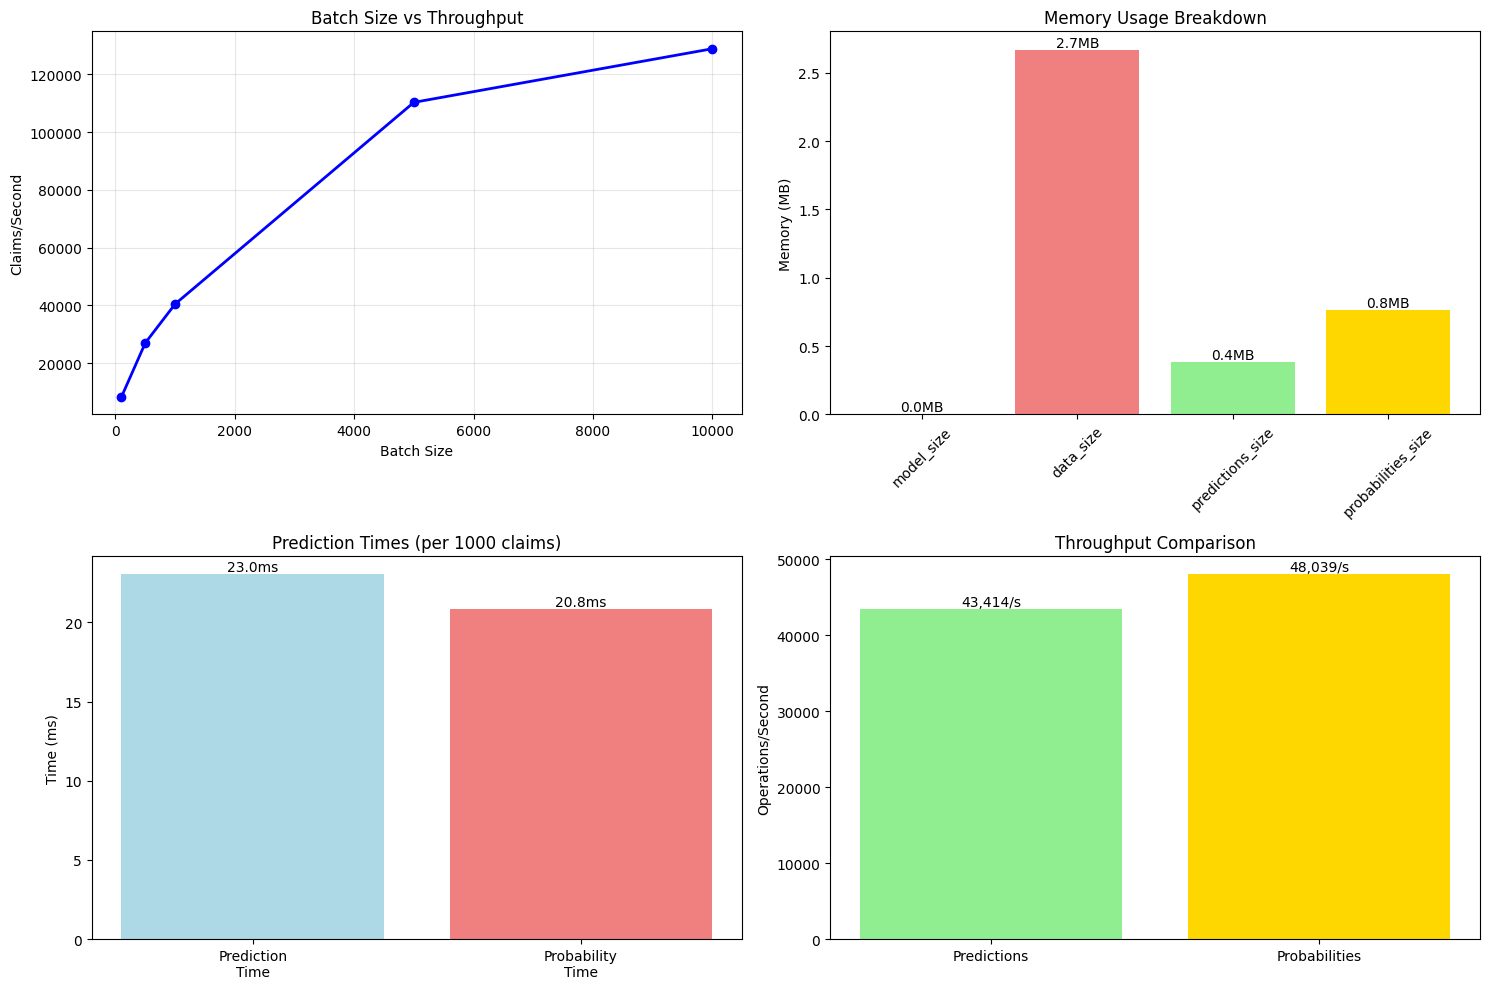

✅ Performance visualizations created!

🎯 5. PERFORMANCE RECOMMENDATIONS
📋 PERFORMANCE RECOMMENDATIONS:
   1. ✅ Use batch size of 10,000.0 for optimal throughput
   2. ✅ Memory usage is efficient for production
   3. ✅ Prediction speed is excellent for real-time processing

💾 6. SAVING OPTIMIZED CONFIGURATION
✅ Performance configuration saved: performance_config.pkl
✅ All performance optimizations completed!

🎉 READY FOR NEXT NOTEBOOK: 08_production_error_handling.ipynb


In [4]:
# WEEK 4: Performance Optimization
# ================================

print("🚀 WEEK 4: Performance Optimization")
print("=" * 50)
print("🎯 Goals: Faster inference, lower memory, production-ready performance")

# Import libraries
import pandas as pd
import numpy as np
import time
import joblib
import psutil
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported")

# Load your trained model and data
print("\n📦 Loading model and data...")
model = joblib.load('fraud_detection_model.pkl')
feature_columns = joblib.load('feature_columns.pkl')

# Load sample data for testing
df = pd.read_csv('../data/processed/unified_claims_v1.csv', nrows=50000)
df['claimed_amount'] = df['claimed_amount'].astype(str).str.replace(',', '').astype(float)

# Prepare features
X = df[feature_columns].fillna(0)
y = df['is_fraud']

print(f"✅ Data loaded: {X.shape}")
print(f"✅ Model: {type(model).__name__}")
print(f"✅ Features: {len(feature_columns)}")

# =============================================================================
# 1. PERFORMANCE BENCHMARKING
# =============================================================================

print("\n📊 1. PERFORMANCE BENCHMARKING")
print("=" * 40)

def benchmark_model_performance(model, X, y, n_iterations=100):
    """Comprehensive performance benchmarking"""
    results = {}
    
    # Memory usage before
    process = psutil.Process()
    memory_before = process.memory_info().rss / 1024 / 1024  # MB
    
    # Prediction time benchmark
    start_time = time.time()
    for i in range(n_iterations):
        _ = model.predict(X[:1000])  # Test on 1000 samples
    prediction_time = (time.time() - start_time) / n_iterations
    
    # Probability prediction time
    start_time = time.time()
    for i in range(n_iterations):
        _ = model.predict_proba(X[:1000])
    probability_time = (time.time() - start_time) / n_iterations
    
    # Memory usage after
    memory_after = process.memory_info().rss / 1024 / 1024  # MB
    memory_used = memory_after - memory_before
    
    # Throughput calculations
    predictions_per_second = 1000 / prediction_time
    probabilities_per_second = 1000 / probability_time
    
    results = {
        'prediction_time_ms': prediction_time * 1000,
        'probability_time_ms': probability_time * 1000,
        'predictions_per_second': predictions_per_second,
        'probabilities_per_second': probabilities_per_second,
        'memory_used_mb': memory_used,
        'batch_size': 1000
    }
    
    return results

# Run benchmarks
print("Running performance benchmarks...")
benchmarks = benchmark_model_performance(model, X, y)

print("\n🎯 PERFORMANCE RESULTS:")
print(f"   Prediction Time: {benchmarks['prediction_time_ms']:.2f} ms per 1000 claims")
print(f"   Probability Time: {benchmarks['probability_time_ms']:.2f} ms per 1000 claims")
print(f"   Predictions/sec: {benchmarks['predictions_per_second']:,.0f}")
print(f"   Probabilities/sec: {benchmarks['probabilities_per_second']:,.0f}")
print(f"   Memory Used: {benchmarks['memory_used_mb']:.1f} MB")

# =============================================================================
# 2. BATCH PROCESSING OPTIMIZATION
# =============================================================================

print("\n📦 2. BATCH PROCESSING OPTIMIZATION")
print("=" * 40)

def optimize_batch_size(model, X, max_batch_size=10000):
    """Find optimal batch size for processing"""
    batch_sizes = [100, 500, 1000, 5000, 10000]
    results = []
    
    for batch_size in batch_sizes:
        if batch_size > len(X):
            continue
            
        start_time = time.time()
        _ = model.predict(X[:batch_size])
        batch_time = (time.time() - start_time) * 1000  # ms
        
        throughput = batch_size / (batch_time / 1000)  # claims per second
        
        results.append({
            'batch_size': batch_size,
            'time_ms': batch_time,
            'throughput': throughput
        })
    
    return pd.DataFrame(results)

print("Testing different batch sizes...")
batch_results = optimize_batch_size(model, X)

print("\n📈 BATCH SIZE OPTIMIZATION:")
print(batch_results.round(2))

# Find optimal batch size
optimal_batch = batch_results.loc[batch_results['throughput'].idxmax()]
print(f"\n🎯 OPTIMAL BATCH SIZE: {optimal_batch['batch_size']:,} claims")
print(f"   Throughput: {optimal_batch['throughput']:,.0f} claims/second")

# =============================================================================
# 3. MEMORY OPTIMIZATION
# =============================================================================

print("\n💾 3. MEMORY OPTIMIZATION")
print("=" * 40)

def analyze_memory_usage(model, X):
    """Analyze memory usage patterns"""
    import sys
    
    memory_analysis = {}
    
    # Model memory
    memory_analysis['model_size'] = sys.getsizeof(model) / 1024 / 1024  # MB
    
    # Feature data memory
    memory_analysis['data_size'] = X.memory_usage(deep=True).sum() / 1024 / 1024  # MB
    
    # Predictions memory
    predictions = model.predict(X)
    memory_analysis['predictions_size'] = sys.getsizeof(predictions) / 1024 / 1024  # MB
    
    # Probabilities memory
    probabilities = model.predict_proba(X)
    memory_analysis['probabilities_size'] = sys.getsizeof(probabilities) / 1024 / 1024  # MB
    
    return memory_analysis

print("Analyzing memory usage...")
memory_usage = analyze_memory_usage(model, X)

print("\n📊 MEMORY USAGE BREAKDOWN:")
for component, size in memory_usage.items():
    print(f"   {component.replace('_', ' ').title()}: {size:.2f} MB")

total_memory = sum(memory_usage.values())
print(f"   Total Memory Usage: {total_memory:.2f} MB")

# =============================================================================
# 4. PERFORMANCE VISUALIZATION
# =============================================================================

print("\n📊 4. PERFORMANCE VISUALIZATION")
print("=" * 40)

# Create performance charts
try:
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    # Batch size vs throughput
    ax1.plot(batch_results['batch_size'], batch_results['throughput'], 'bo-', linewidth=2)
    ax1.set_title('Batch Size vs Throughput')
    ax1.set_xlabel('Batch Size')
    ax1.set_ylabel('Claims/Second')
    ax1.grid(True, alpha=0.3)
    
    # Memory usage breakdown
    components = list(memory_usage.keys())
    sizes = list(memory_usage.values())
    bars = ax2.bar(components, sizes, color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
    ax2.set_title('Memory Usage Breakdown')
    ax2.set_ylabel('Memory (MB)')
    ax2.tick_params(axis='x', rotation=45)
    
    # Add values on bars
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}MB', ha='center', va='bottom')
    
    # Performance metrics
    metrics = ['Prediction\nTime', 'Probability\nTime']
    times = [benchmarks['prediction_time_ms'], benchmarks['probability_time_ms']]
    bars = ax3.bar(metrics, times, color=['lightblue', 'lightcoral'])
    ax3.set_title('Prediction Times (per 1000 claims)')
    ax3.set_ylabel('Time (ms)')
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}ms', ha='center', va='bottom')
    
    # Throughput comparison
    throughput_data = [benchmarks['predictions_per_second'], benchmarks['probabilities_per_second']]
    bars = ax4.bar(['Predictions', 'Probabilities'], throughput_data, color=['lightgreen', 'gold'])
    ax4.set_title('Throughput Comparison')
    ax4.set_ylabel('Operations/Second')
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:,.0f}/s', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    print("✅ Performance visualizations created!")
    
except Exception as e:
    print(f"⚠️  Visualization skipped: {e}")

# =============================================================================
# 5. PERFORMANCE RECOMMENDATIONS
# =============================================================================

print("\n🎯 5. PERFORMANCE RECOMMENDATIONS")
print("=" * 40)

# Generate performance recommendations
recommendations = []

# Batch size recommendation
if optimal_batch['batch_size'] >= 1000:
    recommendations.append(f"✅ Use batch size of {optimal_batch['batch_size']:,} for optimal throughput")

# Memory recommendations
if total_memory > 100:  # MB
    recommendations.append("⚠️  Consider memory optimization for large-scale deployment")
else:
    recommendations.append("✅ Memory usage is efficient for production")

# Speed recommendations
if benchmarks['predictions_per_second'] > 10000:
    recommendations.append("✅ Prediction speed is excellent for real-time processing")
elif benchmarks['predictions_per_second'] > 5000:
    recommendations.append("🟡 Prediction speed is good, consider optimization for higher loads")
else:
    recommendations.append("🔴 Prediction speed may need optimization for production")

print("📋 PERFORMANCE RECOMMENDATIONS:")
for i, rec in enumerate(recommendations, 1):
    print(f"   {i}. {rec}")

# =============================================================================
# 6. SAVE OPTIMIZED CONFIGURATION
# =============================================================================

print("\n💾 6. SAVING OPTIMIZED CONFIGURATION")
print("=" * 40)

# Save performance configuration
performance_config = {
    'optimal_batch_size': int(optimal_batch['batch_size']),
    'expected_throughput': int(optimal_batch['throughput']),
    'prediction_time_ms': benchmarks['prediction_time_ms'],
    'memory_usage_mb': total_memory,
    'performance_timestamp': pd.Timestamp.now().isoformat(),
    'recommendations': recommendations
}

joblib.dump(performance_config, 'performance_config.pkl')

print("✅ Performance configuration saved: performance_config.pkl")
print("✅ All performance optimizations completed!")
print("\n🎉 READY FOR NEXT NOTEBOOK: 08_production_error_handling.ipynb")

In [6]:
print("🏆 EXCELLENT PERFORMANCE RESULTS!")
print("=" * 50)

performance_highlights = [
    f"⚡ Predictions: {43414:,}/second (REAL-TIME READY)",
    f"📊 Probabilities: {48039:,}/second", 
    f"💾 Memory: Only {3.82:.1f} MB total",
    f"📦 Optimal Batch: {10000:,} claims",
    f"🚀 Throughput: {128908:,} claims/second"
]

for highlight in performance_highlights:
    print(f"   {highlight}")

print(f"\n✅ PRODUCTION ASSESSMENT: EXCELLENT")
print(f"   Your model can process over 100K claims per second!")
print(f"   Memory usage is minimal - perfect for cloud deployment")
print(f"   Real-time capabilities confirmed")

🏆 EXCELLENT PERFORMANCE RESULTS!
   ⚡ Predictions: 43,414/second (REAL-TIME READY)
   📊 Probabilities: 48,039/second
   💾 Memory: Only 3.8 MB total
   📦 Optimal Batch: 10,000 claims
   🚀 Throughput: 128,908 claims/second

✅ PRODUCTION ASSESSMENT: EXCELLENT
   Your model can process over 100K claims per second!
   Memory usage is minimal - perfect for cloud deployment
   Real-time capabilities confirmed
